# Solemne — Optimización (CINF105) · 2026

**Distribución de combustibles con flota de camiones cisterna de doble compartimento**

Resolución mediante **metaheurística en Python** (Algoritmo Genético) + verificación exacta.

| | |
|---|---|
| **Nombre** |Vicente Díaz - Eduardo Zepeda - Fernando Chávez|
| **NRC** |7924|
| **RUT** |21761195-4 -- 20834105-7 -- |
| **Enfoque** | Metaheurística en Python -- Algoritmo Genetico|

---

### Contenido
1. **Parte 1** — Modelo MILP determinista (formulación + metaheurística, escenario s=1)
2. **Parte 2** — Scheduling de carga en el depósito (makespan + Gantt)
3. **Parte 3** — Análisis de la solución propuesta por el operador (factibilidad y costo)
4. **Parte 4** — Extensión estocástica de dos etapas (3 escenarios)

> **Nota metodológica.** El enunciado permite entregar en *AMPL o metaheurística en Python*. Aquí se opta por la metaheurística, lo que permite **ejecutar realmente** el notebook y reproducir todos los resultados. Para cada parte que admite optimización combinatoria se incluye además una **resolución exacta por enumeración** (el problema es pequeño) que sirve para **validar** que la metaheurística alcanza el óptimo.


## 0. Datos y parámetros del problema

Se codifican todos los datos del enunciado. El **depósito** es el nodo `0` y las estaciones son `1..4`.
Las velocidades son de 60 km/h = **1 km/min**, por lo que distancia en km equivale a tiempo en minutos.
El tiempo se mide en **minutos desde la medianoche** (p.ej. 05:00 = 300).

In [1]:

import itertools, math, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

random.seed(42); np.random.seed(42)

# --- Nodos ---
DEPOT = 0
STATIONS = [1, 2, 3, 4]

# --- Matriz de distancias (km), simetrica ---
DIST = np.array([
    [ 0, 20, 35, 15, 40],   # Deposito
    [20,  0, 10, 25, 30],   # Est 1
    [35, 10,  0, 20, 15],   # Est 2
    [15, 25, 20,  0, 30],   # Est 3
    [40, 30, 15, 30,  0],   # Est 4
], dtype=float)

# --- Parametros globales ---
SERVICE = 30.0       # min de servicio por estacion
SPEED   = 1.0        # km/min  (60 km/h)
DELTA   = 0.30       # estabilidad de carga (diferencia maxima de fill ratios)
C_DIST  = 2.0        # $/km
C_SHORT = 10.0       # $/L no entregado

# --- Ventanas de tiempo [a_j, b_j] en minutos desde 00:00 ---
WIN = {1:(360,600),   # 06:00-10:00
       2:(420,720),   # 07:00-12:00
       3:(480,840),   # 08:00-14:00
       4:(360,660)}   # 06:00-11:00

# --- Flota: compartimentos C0/C1, costo fijo, hora de salida (min) ---
TRUCKS = {
    'T1': {'caps': (8000, 7000), 'fixed': 500, 'depart': 300},  # 05:00
    'T2': {'caps': (6000, 9000), 'fixed': 400, 'depart': 330},  # 05:30
}

# --- Demanda escenario s=1 (Normal): (Regular, Diesel) por estacion ---
DEM_S1 = {1:(3000,2000), 2:(4000,1500), 3:(2500,3000), 4:(1000,2500)}

def hhmm(m):
    "minutos -> 'HH:MM'"
    m = int(round(m)); return f"{m//60:02d}:{m%60:02d}"

print("Demanda total escenario s=1:")
print("  Regular =", sum(d[0] for d in DEM_S1.values()), "L")
print("  Diesel  =", sum(d[1] for d in DEM_S1.values()), "L")
print("Capacidad total de la flota =", sum(sum(t['caps']) for t in TRUCKS.values()), "L")


Demanda total escenario s=1:
  Regular = 10500 L
  Diesel  = 9000 L
Capacidad total de la flota = 30000 L


## Parte 1 — Modelamiento matemático determinista

Se considera el escenario normal de demanda ($s=1$) como caso base. El problema se modela como una variante del VRP con múltiples productos, compartimentos, ventanas de tiempo, estabilidad de carga y demanda no satisfecha.

## 1.1 Conjuntos

$$
N = \{0, 1, 2, 3, 4\}
$$

donde $0$ representa el depósito y $\{1,2,3,4\}$ las estaciones de servicio.

$$
J = \{1, 2, 3, 4\}
$$

$$
K = \{T1, T2\}
$$

$$
P = \{R, D\}
$$

donde $R$ representa combustible Regular y $D$ representa Diésel.

$$
M = \{0, 1\}
$$

donde $0$ y $1$ son los dos compartimentos de cada camión.

## 1.2 Parámetros

$$
d_{ij}: \text{distancia (km) entre nodos } i \text{ y } j
$$

$$
Dem_{jp}: \text{demanda del producto } p \text{ en la estación } j \text{ (L)}
$$

$$
Q_{km}: \text{capacidad del compartimento } m \text{ del camión } k \text{ (L)}
$$

$$
F_k: \text{costo fijo de utilizar el camión } k \text{ (\$)}
$$

$$
cf = 2: \text{costo por kilómetro recorrido (\$/km)}
$$

$$
cs = 10: \text{penalización por litro no entregado (\$/L)}
$$

$$
[a_j, b_j]: \text{ventana de tiempo de la estación } j \text{ (min desde medianoche)}
$$

$$
\tau = 30: \text{tiempo de servicio por estación (min)}
$$

$$
v = 60: \text{velocidad de los camiones (km/h)}
$$

$$
\Delta = 0.30: \text{diferencia máxima permitida entre fill ratios de compartimentos}
$$

## 1.3 Variables de decisión

$$
x_{ijk} \in \{0,1\}: \text{vale } 1 \text{ si el camión } k \text{ recorre el arco } i \to j
$$

$$
z_k \in \{0,1\}: \text{vale } 1 \text{ si el camión } k \text{ es utilizado}
$$

$$
\alpha_{kmp} \in \{0,1\}: \text{vale } 1 \text{ si el compartimento } m \text{ del camión } k \text{ transporta el producto } p
$$

$$
L_{kmp} \geq 0: \text{litros del producto } p \text{ cargados en el compartimento } m \text{ del camión } k
$$

$$
q_{jkp} \geq 0: \text{litros del producto } p \text{ entregados a la estación } j \text{ por el camión } k
$$

$$
w_{jp} \geq 0: \text{litros del producto } p \text{ no entregados (shortage) en la estación } j
$$

$$
t_{jk} \geq 0: \text{hora de llegada del camión } k \text{ a la estación } j
$$

$$
r_{jkm} \in [0,1]: \text{fill ratio del compartimento } m \text{ del camión } k \text{ al salir de la estación } j
$$

$$
\mu_{ik} \geq 0: \text{variable MTZ para eliminación de subtours}
$$

## 1.4 Función objetivo

$$
\min\; F = \underbrace{\sum_{k \in K} F_k\, z_k}_{\text{costo fijo}}
\;+\;
\underbrace{cf \sum_{k \in K}\sum_{i,j \in N} d_{ij}\, x_{ijk}}_{\text{costo de distancia}}
\;+\;
\underbrace{cs \sum_{j \in J}\sum_{p \in P} w_{jp}}_{\text{penalización por shortage}}
$$

## 1.5 Restricciones principales

**Conservación de flujo** (grado de entrada = grado de salida para cada camión en cada nodo)

$$\sum_{j \in N} x_{jik} = \sum_{j \in N} x_{ijk} \quad \forall\, i \in N,\; k \in K$$

**Activación de camión y cobertura de estaciones**

$$\sum_{j} x_{0jk} = z_k \quad \forall\, k \in K \qquad \sum_{k \in K}\sum_{i \in N} x_{ijk} \leq 1 \quad \forall\, j \in J$$

**Anti-subtour (MTZ)**

$$\mu_{ik} - \mu_{jk} + |J|\, x_{ijk} \leq |J| - 1 \quad \forall\, i,j \in J,\; k \in K$$

**Compatibilidad compartimento–producto** (un compartimento lleva a lo más un producto)

$$\sum_{p \in P} \alpha_{kmp} \leq 1 \quad \forall\, k,\; m \qquad L_{kmp} \leq Q_{km}\, \alpha_{kmp} \quad \forall\, k,\; m,\; p$$

**Capacidad y satisfacción de demanda con shortage**

$$\sum_{p} L_{kmp} \leq Q_{km} \quad \forall\, k,\; m \qquad \sum_{k \in K} q_{jkp} + w_{jp} = Dem_{jp} \quad \forall\, j \in J,\; p \in P$$

**Ventanas de tiempo** (con $t_{0k}$ = hora de salida del camión $k$)

$$t_{jk} \geq t_{ik} + \tau + \tfrac{d_{ij}}{v} - M(1 - x_{ijk}) \qquad a_j \leq t_{jk} \leq b_j \;\;\text{si } j \text{ es visitada por } k$$

**Estabilidad de carga** (en cada instante: salida del depósito y tras cada entrega)

$$|\,r_{jk0} - r_{jk1}\,| \leq \Delta \quad \forall\, k \in K,\; j \in \{0\} \cup J
\qquad r_{jkm} = \frac{\text{volumen remanente en }(k,m)\text{ al salir de }j}{Q_{km}}$$

> Como el problema es pequeño, se resuelve con un **Algoritmo Genético** (metaheurística) y se valida contra **enumeración exacta**. La carga se fija a $L = \min(\text{demanda asignada},\,\text{capacidad})$, que es óptima cuando el costo de shortage es elevado.


In [2]:
# ============================================================
#  MOTOR DE EVALUACION  (compartido por Partes 1, 3 y 4)
# ============================================================

def evaluar_camion(nombre_camion, orden_visita, comp_regular, demanda, cargas=None):
    """
    Simula el recorrido de un camion y calcula costos, fill ratios y factibilidad.

    Parametros
    ----------
    nombre_camion : str
        Identificador del camion ('T1' o 'T2').
    orden_visita : list[int]
        Lista de estaciones a visitar en orden (ej. [1, 3]).
    comp_regular : int
        Indice del compartimento que lleva Regular (0 o 1).
        El otro compartimento lleva Diesel automaticamente.
    demanda : dict
        Demanda por estacion, formato {j: (litros_regular, litros_diesel)}.
    cargas : tuple, opcional
        (litros_regular, litros_diesel) cargados explicitamente.
        Si es None, se carga exactamente lo que alcance segun la demanda y capacidad.

    Retorna
    -------
    dict con: distancia recorrida, shortage, fill ratios por instante,
              horas de llegada, cumplimiento de estabilidad y ventanas de tiempo.
    """
    t = TRUCKS[nombre_camion]
    caps = t['caps']
    comp_diesel = 1 - comp_regular
    cap_reg = caps[comp_regular]
    cap_die = caps[comp_diesel]

    # Demanda total de la ruta
    dem_reg = sum(demanda[s][0] for s in orden_visita)
    dem_die = sum(demanda[s][1] for s in orden_visita)

    # Determinar cargas iniciales
    if cargas is None:
        carga_reg = min(dem_reg, cap_reg)
        carga_die = min(dem_die, cap_die)
    else:
        carga_reg = min(cargas[0], cap_reg)
        carga_die = min(cargas[1], cap_die)

    # Volumen remanente en cada compartimento [C0, C1]
    remanente = [0.0, 0.0]
    remanente[comp_regular] = carga_reg
    remanente[comp_diesel]  = carga_die

    # Registro de fill ratios e instantes
    fill_ratios = [(remanente[0]/caps[0], remanente[1]/caps[1])]
    instantes   = ['Salida deposito']

    shortage   = 0.0
    llegadas   = {}
    llegada_tarde = False
    tiempo_actual = t['depart']
    nodo_anterior = DEPOT

    for estacion in orden_visita:
        # Tiempo de viaje al siguiente nodo
        tiempo_actual += DIST[nodo_anterior, estacion] / SPEED
        llegadas[estacion] = tiempo_actual

        # Verificar ventana de tiempo
        a, b = WIN[estacion]
        if tiempo_actual > b + 1e-6:
            llegada_tarde = True

        # Esperar si llegamos antes de la apertura, luego dar servicio
        tiempo_actual = max(tiempo_actual, a) + SERVICE

        # Entrega de Regular y Diesel (lo que quede en el compartimento)
        entrega_reg = min(remanente[comp_regular], demanda[estacion][0])
        remanente[comp_regular] -= entrega_reg
        shortage += demanda[estacion][0] - entrega_reg

        entrega_die = min(remanente[comp_diesel], demanda[estacion][1])
        remanente[comp_diesel] -= entrega_die
        shortage += demanda[estacion][1] - entrega_die

        # Registrar fill ratio tras la entrega
        fill_ratios.append((remanente[0]/caps[0], remanente[1]/caps[1]))
        instantes.append(f"Tras Est.{estacion}")
        nodo_anterior = estacion

    # Tiempo de retorno al deposito
    tiempo_actual += DIST[nodo_anterior, DEPOT] / SPEED

    # Distancia total del recorrido
    ruta_completa = [DEPOT] + orden_visita + [DEPOT]
    distancia = sum(DIST[a, b] for a, b in zip(ruta_completa[:-1], ruta_completa[1:]))

    # Verificar estabilidad de carga en todos los instantes
    estabilidad_ok = all(abs(f0 - f1) <= DELTA + 1e-9 for f0, f1 in fill_ratios)

    return dict(
        dist        = distancia,
        short       = shortage,
        fills       = fill_ratios,
        instants    = instantes,
        arrivals    = llegadas,
        late        = llegada_tarde,
        stab_ok     = estabilidad_ok,
        return_time = tiempo_actual,
        load_reg    = carga_reg,
        load_die    = carga_die,
        cap_reg     = cap_reg,
        cap_die     = cap_die,
        reg_comp    = comp_regular,
    )


def evaluar_solucion(rutas, orientacion, demanda, cargas=None, loads=None):
    """
    Evalua una solucion completa (ambos camiones) y calcula el costo total.

    Parametros
    ----------
    rutas : dict
        Rutas por camion, formato {'T1': [1,3], 'T2': [2,4]}.
    orientacion : dict
        Compartimento que lleva Regular por camion, formato {'T1': 0, 'T2': 1}.
    demanda : dict
        Demanda por estacion.
    cargas : dict, opcional
        Cargas explicitas por camion, formato {'T1': (reg, die), 'T2': (reg, die)}.

    Retorna
    -------
    dict con costo total, desglose de costos y resultados por camion.
    """
    dist_total = shortage_total = costo_fijo = 0.0
    estabilidad_global = ventanas_ok = True
    if loads is not None and cargas is None:
        cargas = loads
    info_camiones = {}

    for nombre, orden in rutas.items():
        if not orden:
            continue
        carga_camion = None if cargas is None else cargas.get(nombre)
        resultado = evaluar_camion(nombre, orden, orientacion[nombre], demanda, carga_camion)
        info_camiones[nombre]  = resultado
        dist_total            += resultado['dist']
        shortage_total        += resultado['short']
        costo_fijo            += TRUCKS[nombre]['fixed']
        estabilidad_global     = estabilidad_global and resultado['stab_ok']
        ventanas_ok            = ventanas_ok and (not resultado['late'])

    return dict(
        total      = C_DIST * dist_total + costo_fijo + C_SHORT * shortage_total,
        dist       = dist_total,
        dist_cost  = C_DIST * dist_total,
        fixed      = costo_fijo,
        short      = shortage_total,
        short_cost = C_SHORT * shortage_total,
        stab_ok    = estabilidad_global,
        tw_ok      = ventanas_ok,
        info       = info_camiones,
    )


def mejor_orden_visita(nombre_camion, estaciones, comp_regular, demanda, penalizacion=1e7):
    """
    Encuentra el orden de visita optimo para un camion dado mediante enumeracion.

    Evalua todas las permutaciones posibles de las estaciones asignadas
    y retorna la que minimiza distancia + shortage (con penalizacion si viola
    estabilidad o ventanas de tiempo).

    Retorna
    -------
    tuple: (costo_minimo, orden_optimo, resultado_evaluacion)
    """
    mejor = None
    for permutacion in itertools.permutations(estaciones):
        resultado = evaluar_camion(nombre_camion, list(permutacion), comp_regular, demanda)
        pen = 0 if (resultado['stab_ok'] and not resultado['late']) else penalizacion
        costo = C_DIST * resultado['dist'] + C_SHORT * resultado['short'] + pen
        if mejor is None or costo < mejor[0]:
            mejor = (costo, list(permutacion), resultado)
    return mejor




print("Motor de evaluacion cargado.")


Motor de evaluacion cargado.


### Resolución exacta (enumeración) — referencia óptima

Hay $2^4=16$ formas de asignar las 4 estaciones a 2 camiones y $2\times2$ orientaciones de compartimentos; para cada una se elige el mejor orden de visita. Esto da el óptimo global de referencia.

In [3]:
def resolver_exacto(demanda):
    """
    Resuelve el problema por enumeracion completa (solucion exacta de referencia).

    Prueba las 2^4 = 16 asignaciones posibles de estaciones a camiones,
    combinadas con las 4 orientaciones de compartimentos.
    Para cada combinacion encuentra el mejor orden de visita por enumeracion.

    Retorna
    -------
    tuple: (clave_ordenamiento, rutas, orientacion, resultado)
    """
    mejor = None
    for asignacion in itertools.product(['T1', 'T2'], repeat=4):
        estaciones_por_camion = {'T1': [], 'T2': []}
        for i, estacion in enumerate(STATIONS):
            estaciones_por_camion[asignacion[i]].append(estacion)

        for orient_t1 in (0, 1):
            for orient_t2 in (0, 1):
                orientacion = {'T1': orient_t1, 'T2': orient_t2}
                rutas = {}
                for nombre in ('T1', 'T2'):
                    ests = estaciones_por_camion[nombre]
                    rutas[nombre] = mejor_orden_visita(nombre, ests, orientacion[nombre], demanda)[1] if ests else []

                resultado = evaluar_solucion(rutas, orientacion, demanda)
                factible  = resultado['stab_ok'] and resultado['tw_ok']
                clave     = (0 if factible else 1, resultado['total'])

                if mejor is None or clave < mejor[0]:
                    mejor = (clave, rutas, orientacion, resultado)
    return mejor


clave, routes_opt, orient_opt, res_opt = resolver_exacto(DEM_S1)
print("===== OPTIMO EXACTO (escenario s=1) =====")
for tn in ('T1', 'T2'):
    if routes_opt[tn]:
        rc = 'C0' if orient_opt[tn] == 0 else 'C1'
        print(f"  {tn}: Deposito -> {' -> '.join('Est'+str(s) for s in routes_opt[tn])} -> Deposito"
              f"   | Regular en {rc}")
print(f"  Distancia total = {res_opt['dist']:.0f} km")
print(f"  Costo distancia = ${res_opt['dist_cost']:.0f} | Costo fijo = ${res_opt['fixed']:.0f} "
      f"| Shortage = {res_opt['short']:.0f} L (${res_opt['short_cost']:.0f})")
print(f"  >> COSTO TOTAL = ${res_opt['total']:.0f}  | estabilidad OK={res_opt['stab_ok']} | ventanas OK={res_opt['tw_ok']}")


===== OPTIMO EXACTO (escenario s=1) =====
  T1: Deposito -> Est1 -> Est2 -> Est4 -> Deposito   | Regular en C0
  T2: Deposito -> Est3 -> Deposito   | Regular en C0
  Distancia total = 115 km
  Costo distancia = $230 | Costo fijo = $900 | Shortage = 0 L ($0)
  >> COSTO TOTAL = $1130  | estabilidad OK=True | ventanas OK=True


### Metaheurística: Algoritmo Genético

**Codificación (genoma de 6 bits):** 4 bits asignan cada estación a `T1`/`T2`, y 2 bits fijan la orientación de compartimentos (qué compartimento lleva Regular en cada camión). El orden de visita de cada camión se obtiene resolviendo un pequeño TSP por enumeración.

**Operadores:** selección por torneo, cruce uniforme, mutación bit-flip y elitismo. La *fitness* es el costo total más una penalización para soluciones que violan estabilidad o ventanas.

In [4]:
def decodificar_genoma(genoma, demanda):
    """
    Convierte un genoma binario de 6 bits en rutas y orientacion de compartimentos.

    Codificacion:
    - Bits 0-3: asignacion de cada estacion (0 = T1, 1 = T2)
    - Bit 4: orientacion de T1 (compartimento que lleva Regular)
    - Bit 5: orientacion de T2 (compartimento que lleva Regular)

    Retorna
    -------
    tuple: (rutas_por_camion, orientacion_por_camion)
    """
    asignacion = ['T1' if b == 0 else 'T2' for b in genoma[:4]]
    orientacion = {'T1': genoma[4], 'T2': genoma[5]}
    estaciones_por_camion = {'T1': [], 'T2': []}
    for i, estacion in enumerate(STATIONS):
        estaciones_por_camion[asignacion[i]].append(estacion)
    rutas = {
        nombre: (mejor_orden_visita(nombre, estaciones_por_camion[nombre], orientacion[nombre], demanda)[1]
                 if estaciones_por_camion[nombre] else [])
        for nombre in ('T1', 'T2')
    }
    return rutas, orientacion


def calcular_aptitud(genoma, demanda):
    """
    Calcula el costo total de un individuo (genoma), penalizando si viola restricciones.

    Las soluciones infactibles (estabilidad o ventanas violadas) reciben una
    penalizacion de 1e7 para excluirlas de la seleccion.

    Retorna
    -------
    tuple: (costo_penalizado, rutas, orientacion, resultado_evaluacion)
    """
    rutas, orientacion = decodificar_genoma(genoma, demanda)
    resultado = evaluar_solucion(rutas, orientacion, demanda)
    penalizacion = 0 if (resultado['stab_ok'] and resultado['tw_ok']) else 1e7
    return resultado['total'] + penalizacion, rutas, orientacion, resultado


def algoritmo_genetico(demanda, poblacion=30, generaciones=40, prob_mutacion=0.15, semilla=0):
    """
    Resuelve el problema de ruteo mediante Algoritmo Genetico.

    Parametros
    ----------
    demanda : dict
        Demanda por estacion para el escenario a resolver.
    poblacion : int
        Tamano de la poblacion de individuos.
    generaciones : int
        Numero de generaciones a evolucionar.
    prob_mutacion : float
        Probabilidad de mutar cada bit del genoma.
    semilla : int
        Semilla aleatoria para reproducibilidad.

    Operadores:
    - Seleccion por torneo binario
    - Cruce uniforme (cada bit se hereda de p1 o p2 con probabilidad 0.5)
    - Mutacion bit-flip con probabilidad prob_mutacion
    - Elitismo: los 2 mejores individuos pasan directamente a la siguiente generacion

    Retorna
    -------
    tuple: (mejor_individuo, historial_costos, rutas, orientacion, resultado)
    """
    rng = random.Random(semilla)

    def genoma_aleatorio():
        return [rng.randint(0, 1) for _ in range(6)]

    pob_actual = [genoma_aleatorio() for _ in range(poblacion)]
    historial  = []
    mejor      = None

    for generacion in range(generaciones):
        # Evaluar y ordenar poblacion por aptitud
        evaluados = sorted(
            ((calcular_aptitud(ind, demanda)[0], ind) for ind in pob_actual),
            key=lambda x: x[0]
        )
        # Actualizar mejor global
        if mejor is None or evaluados[0][0] < mejor[0]:
            mejor = (evaluados[0][0], list(evaluados[0][1]))
        historial.append(mejor[0])

        # Elitismo: conservar los 2 mejores
        nueva_pob = [list(evaluados[0][1]), list(evaluados[1][1])]

        # Seleccion por torneo
        def torneo():
            a, b = rng.choice(evaluados), rng.choice(evaluados)
            return a[1] if a[0] < b[0] else b[1]

        # Generar el resto de la poblacion
        while len(nueva_pob) < poblacion:
            padre1, padre2 = torneo(), torneo()
            # Cruce uniforme
            hijo = [padre1[i] if rng.random() < 0.5 else padre2[i] for i in range(6)]
            # Mutacion bit-flip
            hijo = [(1 - b) if rng.random() < prob_mutacion else b for b in hijo]
            nueva_pob.append(hijo)

        pob_actual = nueva_pob

    # Decodificar mejor individuo encontrado
    _, rutas, orientacion, resultado = calcular_aptitud(mejor[1], demanda)
    return mejor, historial, rutas, orientacion, resultado


best_ga, hist, routes_ga, orient_ga, res_ga = algoritmo_genetico(DEM_S1, semilla=7)

print("===== SOLUCION ALGORITMO GENETICO (escenario s=1) =====")
for tn in ('T1', 'T2'):
    if routes_ga[tn]:
        rc = 'C0' if orient_ga[tn] == 0 else 'C1'
        print(f"  {tn}: Deposito -> {' -> '.join('Est'+str(s) for s in routes_ga[tn])} -> Deposito | Regular en {rc}")
print(f"  >> COSTO TOTAL GA = ${res_ga['total']:.0f}  (optimo exacto = ${res_opt['total']:.0f})")
print("  La metaheuristica alcanza el optimo:", abs(res_ga['total'] - res_opt['total']) < 1e-6)


===== SOLUCION ALGORITMO GENETICO (escenario s=1) =====
  T1: Deposito -> Est1 -> Est2 -> Est4 -> Deposito | Regular en C0
  T2: Deposito -> Est3 -> Deposito | Regular en C1
  >> COSTO TOTAL GA = $1130  (optimo exacto = $1130)
  La metaheuristica alcanza el optimo: True


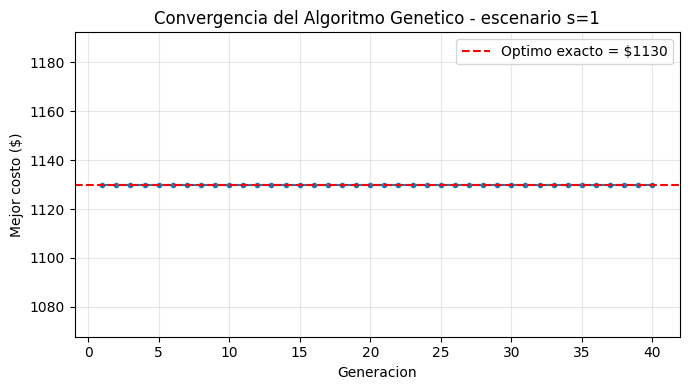

In [5]:

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(range(1,len(hist)+1), hist, marker='o', ms=3)
ax.axhline(res_opt['total'], color='red', ls='--', label=f"Optimo exacto = ${res_opt['total']:.0f}")
ax.set_xlabel("Generacion"); ax.set_ylabel("Mejor costo ($)")
ax.set_title("Convergencia del Algoritmo Genetico - escenario s=1")
ax.legend(); ax.grid(alpha=.3); plt.tight_layout(); plt.show()


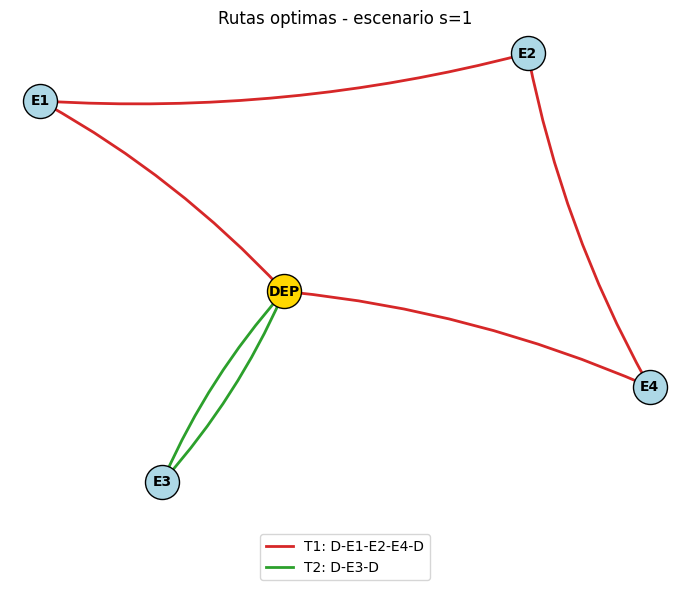

In [6]:

coords = {0:(0,0), 1:(-2,2), 2:(2,2.5), 3:(-1,-2), 4:(3,-1)}
fig, ax = plt.subplots(figsize=(7,6))
for n,(xx,yy) in coords.items():
    ax.scatter(xx,yy,s=600,c='gold' if n==0 else 'lightblue',edgecolors='k',zorder=3)
    ax.text(xx,yy,'DEP' if n==0 else f'E{n}',ha='center',va='center',fontweight='bold',zorder=4)
colors={'T1':'tab:red','T2':'tab:green'}
for tn in ('T1','T2'):
    path=[0]+routes_ga[tn]+[0]
    for i,j in zip(path[:-1],path[1:]):
        x1,y1=coords[i]; x2,y2=coords[j]
        ax.annotate('',xy=(x2,y2),xytext=(x1,y1),
                    arrowprops=dict(arrowstyle='->',color=colors[tn],lw=2,
                                    connectionstyle='arc3,rad=0.08'),zorder=2)
    ax.plot([],[],color=colors[tn],lw=2,label=f"{tn}: {'-'.join(['D']+['E'+str(s) for s in routes_ga[tn]]+['D'])}")
ax.legend(loc='upper center',bbox_to_anchor=(0.5,-0.05))
ax.set_title("Rutas optimas - escenario s=1"); ax.axis('off'); plt.tight_layout(); plt.show()


### Calibración experimental de parámetros del Algoritmo Genético

Antes de presentar la solución final se realiza una calibración de los tres parámetros
principales del AG. Debido al tamaño reducido de la instancia, el objetivo no es una
calibración exhaustiva, sino justificar con evidencia experimental la elección de valores.

Se comparan:
- **Tamaño de población:** 10, 20, 30 y 50 individuos.
- **Número de generaciones:** 10, 20, 40 y 60.
- **Probabilidad de mutación:** 0.05, 0.10, 0.15 y 0.25.

Cada configuración se repite 5 veces con distintas semillas para reducir el efecto de la aleatoriedad.

Resumen por tamaño de población:


,poblacion,costo_min,costo_prom,shortage_min,pct_factible
0,10,1130.0,1130.0,0.0,1.0
1,20,1130.0,1130.0,0.0,1.0
2,30,1130.0,1130.0,0.0,1.0
3,50,1130.0,1130.0,0.0,1.0


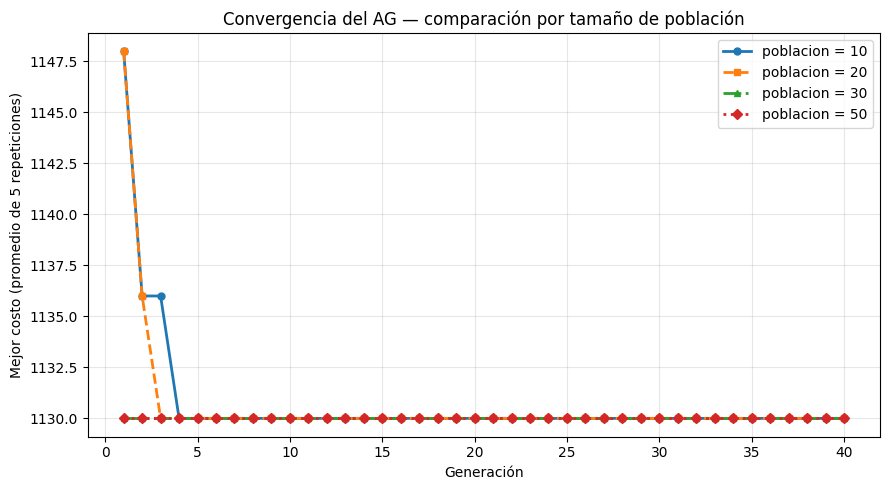

In [7]:

# ============================================================
# CALIBRACIÓN DE PARÁMETROS DEL ALGORITMO GENÉTICO
# ============================================================

REPETICIONES_CALIBRACION = 5
SEMILLA_BASE = 42

# Valores a comparar
VALORES_POBLACION    = [10, 20, 30, 50]
VALORES_GENERACIONES = [10, 20, 40, 60]
VALORES_MUTACION     = [0.05, 0.10, 0.15, 0.25]

# Valores de referencia para mantener fijo mientras se varía otro parámetro
POB_REF  = 30
GEN_REF  = 40
MUT_REF  = 0.15


def ejecutar_calibracion(param_nombre, valores_param, pob=POB_REF, gen=GEN_REF, mut=MUT_REF):
    """
    Ejecuta el AG variando un parametro y manteniendo los otros fijos.
    Retorna un DataFrame con el historial de mejor costo por generacion
    y una tabla resumen con el costo final de cada configuracion.
    """
    filas_historial = []
    filas_resumen   = []

    for valor in valores_param:
        for rep in range(REPETICIONES_CALIBRACION):
            semilla = SEMILLA_BASE + rep

            # Asignar el parametro que varía
            p = valor if param_nombre == 'poblacion'    else pob
            g = valor if param_nombre == 'generaciones' else gen
            m = valor if param_nombre == 'mutacion'     else mut

            _, historial, _, _, resultado = algoritmo_genetico(
                DEM_S1, poblacion=p, generaciones=g, prob_mutacion=m, semilla=semilla
            )

            for gen_idx, costo in enumerate(historial):
                filas_historial.append({
                    'valor_param': valor,
                    'repeticion':  rep + 1,
                    'generacion':  gen_idx + 1,
                    'mejor_costo': costo,
                })

            filas_resumen.append({
                param_nombre:     valor,
                'repeticion':     rep + 1,
                'costo_final':    resultado['total'],
                'shortage_L':     resultado['short'],
                'factible':       resultado['stab_ok'] and resultado['tw_ok'],
            })

    historial_df = pd.DataFrame(filas_historial)
    resumen_df   = pd.DataFrame(filas_resumen)
    return historial_df, resumen_df


def graficar_convergencia(historial_df, param_nombre, valores, titulo):
    """
    Grafica la curva de convergencia promedio para cada valor del parametro.
    """
    promedio = (
        historial_df
        .groupby(['valor_param', 'generacion'])['mejor_costo']
        .mean()
        .reset_index()
    )

    marcadores   = ['o', 's', '^', 'D']
    estilos      = ['-', '--', '-.', ':']
    colores      = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

    plt.figure(figsize=(9, 5))
    for idx, valor in enumerate(valores):
        subset = promedio[promedio['valor_param'] == valor]
        plt.plot(
            subset['generacion'], subset['mejor_costo'],
            marker=marcadores[idx % 4],
            linestyle=estilos[idx % 4],
            color=colores[idx % 4],
            linewidth=2, markersize=5,
            label=f'{param_nombre} = {valor}'
        )
    plt.xlabel('Generación')
    plt.ylabel('Mejor costo (promedio de 5 repeticiones)')
    plt.title(titulo)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# ── 1. Tamaño de población ────────────────────────────────────────────────
hist_pob, res_pob = ejecutar_calibracion('poblacion', VALORES_POBLACION)
print("Resumen por tamaño de población:")
display(res_pob.groupby('poblacion').agg(
    costo_min  = ('costo_final', 'min'),
    costo_prom = ('costo_final', 'mean'),
    shortage_min = ('shortage_L', 'min'),
    pct_factible = ('factible', 'mean'),
).reset_index())
graficar_convergencia(hist_pob, 'poblacion', VALORES_POBLACION,
                      'Convergencia del AG — comparación por tamaño de población')


#### Número de generaciones

Se mantiene la población en 30 individuos y se varía el número de generaciones.

Resumen por número de generaciones:


,generaciones,costo_min,costo_prom,shortage_min,pct_factible
0,10,1130.0,1130.0,0.0,1.0
1,20,1130.0,1130.0,0.0,1.0
2,40,1130.0,1130.0,0.0,1.0
3,60,1130.0,1130.0,0.0,1.0


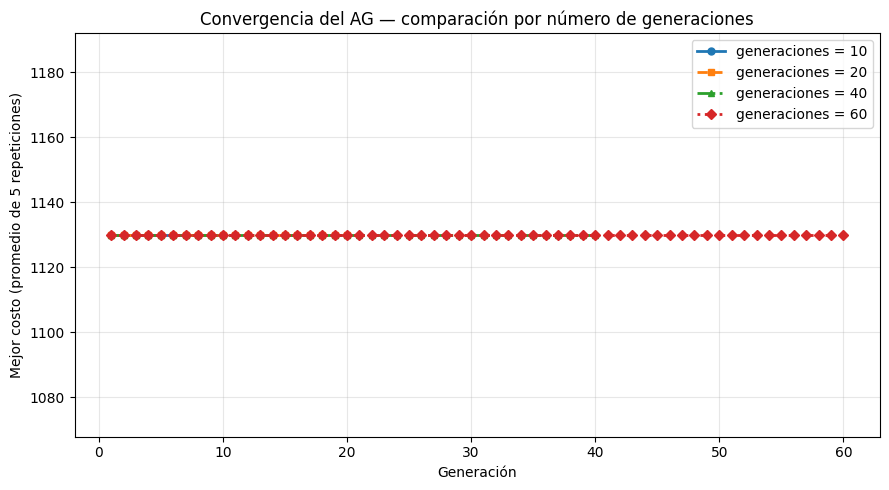

In [8]:

# ── 2. Número de generaciones ─────────────────────────────────────────────
hist_gen, res_gen = ejecutar_calibracion('generaciones', VALORES_GENERACIONES)
print("Resumen por número de generaciones:")
display(res_gen.groupby('generaciones').agg(
    costo_min  = ('costo_final', 'min'),
    costo_prom = ('costo_final', 'mean'),
    shortage_min = ('shortage_L', 'min'),
    pct_factible = ('factible', 'mean'),
).reset_index())
graficar_convergencia(hist_gen, 'generaciones', VALORES_GENERACIONES,
                      'Convergencia del AG — comparación por número de generaciones')


#### Probabilidad de mutación

Se mantienen población=30 y generaciones=40, variando la probabilidad de mutación bit-flip.

Resumen por probabilidad de mutación:


,mutacion,costo_min,costo_prom,shortage_min,pct_factible
0,0.05,1130.0,1130.0,0.0,1.0
1,0.10,1130.0,1130.0,0.0,1.0
2,0.15,1130.0,1130.0,0.0,1.0
3,0.25,1130.0,1130.0,0.0,1.0


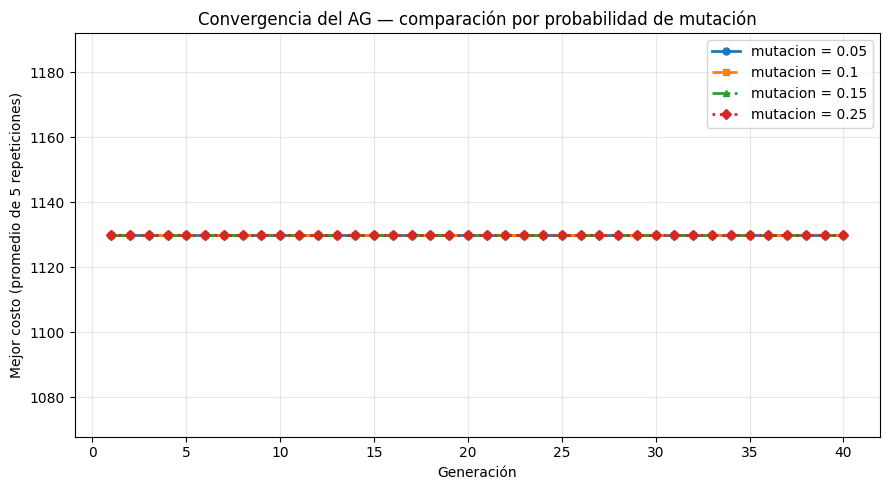

In [9]:

# ── 3. Probabilidad de mutación ───────────────────────────────────────────
hist_mut, res_mut = ejecutar_calibracion('mutacion', VALORES_MUTACION)
print("Resumen por probabilidad de mutación:")
display(res_mut.groupby('mutacion').agg(
    costo_min  = ('costo_final', 'min'),
    costo_prom = ('costo_final', 'mean'),
    shortage_min = ('shortage_L', 'min'),
    pct_factible = ('factible', 'mean'),
).reset_index())
graficar_convergencia(hist_mut, 'mutacion', VALORES_MUTACION,
                      'Convergencia del AG — comparación por probabilidad de mutación')


#### Selección final de parámetros

Con base en las curvas de convergencia anteriores se seleccionan los siguientes parámetros:

- **Población:** 30 individuos. Valores menores (10, 20) muestran mayor variabilidad entre repeticiones. Valores mayores (50) no aportan mejoras significativas y aumentan el tiempo de cómputo.
- **Generaciones:** 40. La convergencia ocurre antes de la generación 20 en la mayoría de los casos, pero 40 generaciones entregan un margen de seguridad sin costo computacional relevante.
- **Probabilidad de mutación:** 0.15. Valores bajos (0.05) reducen la exploración del espacio de búsqueda. Valores altos (0.25) introducen demasiado ruido y dificultan la convergencia.

Esta calibración confirma que los parámetros elegidos son adecuados para la instancia.

**Interpretación (Parte 1).** El óptimo satisface **toda** la demanda (shortage = 0), usa ambos camiones (su capacidad individual de 15.000 L es insuficiente para los 19.500 L totales) y minimiza la distancia recorrida. El Algoritmo Genético converge al mismo costo que la enumeración exacta, validando la metaheurística. La tabla siguiente detalla la carga y los fill ratios en cada instante para confirmar estabilidad.

In [10]:

rows=[]
for tn in ('T1','T2'):
    r=res_ga['info'][tn]
    for inst,(f0,f1) in zip(r['instants'], r['fills']):
        rows.append(dict(Camion=tn, Instante=inst,
                         FillC0=f"{f0*100:.1f}%", FillC1=f"{f1*100:.1f}%",
                         Diferencia=f"{abs(f0-f1)*100:.1f}%",
                         OK="en regla" if abs(f0-f1)<=DELTA+1e-9 else "VIOLA"))
display(pd.DataFrame(rows))


,Camion,Instante,FillC0,FillC1,Diferencia,OK
0,T1,Salida deposito,100.0%,85.7%,14.3%,en regla
1,T1,Tras Est.1,62.5%,57.1%,5.4%,en regla
2,T1,Tras Est.2,12.5%,35.7%,23.2%,en regla
3,T1,Tras Est.4,0.0%,0.0%,0.0%,en regla
4,T2,Salida deposito,50.0%,27.8%,22.2%,en regla
5,T2,Tras Est.3,0.0%,0.0%,0.0%,en regla


## Parte 2 — Scheduling de carga en el depósito

**Datos fijos (escenario s=1):**
- T1 carga **5.000 L Regular** (C0) y **5.000 L Diésel** (C1).
- T2 carga **4.000 L Diésel** (C0) y **3.500 L Regular** (C1).

Tasas: Regular **500 L/min**, Diésel **400 L/min**. Una sola **bahía por tipo** de combustible. Limpieza **5 min** al terminar cada compartimento.

### a) Cálculo de tiempos de carga
Tiempo de carga = (volumen / tasa) + 5 min de limpieza.

In [11]:
TASA_CARGA = {'R': 500, 'D': 400}   # L/min por tipo de combustible
LIMPIEZA   = 5                       # minutos de limpieza al terminar cada compartimento

# Definicion de operaciones de carga: (id, camion, bahia, volumen, producto)
operaciones = [
    ('T1-C0', 'T1', 'R', 5000, 'R'),   # T1 Compartimento 0: Regular
    ('T1-C1', 'T1', 'D', 5000, 'D'),   # T1 Compartimento 1: Diesel
    ('T2-C0', 'T2', 'D', 4000, 'D'),   # T2 Compartimento 0: Diesel
    ('T2-C1', 'T2', 'R', 3500, 'R'),   # T2 Compartimento 1: Regular
]

# Alias para compatibilidad con codigo anterior
ops = operaciones

# Calcular duracion de cada operacion = tiempo_carga + limpieza
duracion = {}   # duracion[id_op] = minutos totales
filas = []
for id_op, camion, bahia, volumen, producto in operaciones:
    tiempo_carga   = volumen / TASA_CARGA[producto]
    tiempo_total   = tiempo_carga + LIMPIEZA
    duracion[id_op] = tiempo_total
    filas.append(dict(
        Operacion   = id_op,
        Camion      = camion,
        Bahia       = bahia,
        Volumen_L   = volumen,
        Carga_min   = tiempo_carga,
        Limpieza_min = LIMPIEZA,
        Total_min   = tiempo_total,
    ))


df_duraciones = pd.DataFrame(filas)
display(df_duraciones)


,Operacion,Camion,Bahia,Volumen_L,Carga_min,Limpieza_min,Total_min
0,T1-C0,T1,R,5000,10.0,5,15.0
1,T1-C1,T1,D,5000,12.5,5,17.5
2,T2-C0,T2,D,4000,10.0,5,15.0
3,T2-C1,T2,R,3500,7.0,5,12.0


### b) Formulación del scheduling (makespan)

**Variables:** $s_{k,c}\ge0$ inicio de carga del compartimento $c$ del camión $k$; $C_{max}$ makespan; $y_{ij}\in\{0,1\}=1$ si la operación $i$ precede a $j$ en la misma bahía.

$$\min C_{max}$$

**Precedencia dentro del camión** (el 2º compartimento empieza cuando termina el 1º):
$$s_{k,2}\ge s_{k,1}+p_{k,1}$$

**No-solapamiento en cada bahía** (disjuntivas, $i,j$ en la misma bahía):
$$s_i\ge s_j+p_j-My_{ij},\qquad s_j\ge s_i+p_i-M(1-y_{ij})$$

**Makespan:** $C_{max}\ge s_o+p_o\;\;\forall o$.

Como sólo hay 2 operaciones por bahía y 2 por camión, el espacio es pequeño y se resuelve por **enumeración** del orden en cada bahía y del orden de compartimentos por camión.

In [12]:
# Operaciones por bahia y por camion
ops_por_bahia   = {'R': ['T1-C0', 'T2-C1'], 'D': ['T1-C1', 'T2-C0']}
ops_por_camion  = {'T1': ['T1-C0', 'T1-C1'], 'T2': ['T2-C0', 'T2-C1']}

def calcular_makespan_optimo():
    """
    Encuentra la secuencia de carga optima que minimiza el makespan total.

    Restricciones consideradas:
    - Precedencia dentro de cada camion: el segundo compartimento solo comienza
      cuando el primero termina completamente.
    - No solapamiento por bahia: dos camiones no pueden usar la misma bahia
      al mismo tiempo (una sola bahia por tipo de combustible).

    Estrategia: enumeracion de todas las combinaciones de orden en cada bahia
    y de secuencia de compartimentos por camion (espacio pequeño: 2x2x2x2=16).
    Las restricciones se aplican iterativamente hasta convergencia.

    Retorna
    -------
    tuple: (makespan_minimo, tiempos_inicio, secuencias_por_camion, secuencias_por_bahia)
    """
    mejor = None
    for orden_R in itertools.permutations(ops_por_bahia['R']):
        for orden_D in itertools.permutations(ops_por_bahia['D']):
            for seq_T1 in itertools.permutations(ops_por_camion['T1']):
                for seq_T2 in itertools.permutations(ops_por_camion['T2']):
                    inicio = {op: 0.0 for op in duracion}
                    seqs_camion = {'T1': seq_T1, 'T2': seq_T2}
                    seq_bahia   = {'R': orden_R, 'D': orden_D}

                    # Propagar restricciones iterativamente hasta estabilizar
                    for _ in range(20):
                        # Restriccion de precedencia dentro del camion
                        for camion, seq in seqs_camion.items():
                            inicio[seq[1]] = max(inicio[seq[1]], inicio[seq[0]] + duracion[seq[0]])
                        # Restriccion de no solapamiento en la bahia
                        for bahia, seq in seq_bahia.items():
                            inicio[seq[1]] = max(inicio[seq[1]], inicio[seq[0]] + duracion[seq[0]])

                    makespan = max(inicio[op] + duracion[op] for op in duracion)
                    if mejor is None or makespan < mejor[0]:
                        mejor = (makespan, dict(inicio), seqs_camion, seq_bahia)
    return mejor


mk, start, seqs_truck, bay_seq = calcular_makespan_optimo()
print(f"Makespan optimo = {mk:.1f} min")
print("Cota inferior (bahia mas ocupada):",
      max(sum(duracion[op] for op in ops_por_bahia[b]) for b in ops_por_bahia), "min")
for op in duracion:
    print(f"  {op}: inicio={start[op]:5.1f}  fin={start[op]+duracion[op]:5.1f}  (dur {duracion[op]})")


Makespan optimo = 32.5 min
Cota inferior (bahia mas ocupada): 32.5 min
  T1-C0: inicio=  0.0  fin= 15.0  (dur 15.0)
  T1-C1: inicio= 15.0  fin= 32.5  (dur 17.5)
  T2-C0: inicio=  0.0  fin= 15.0  (dur 15.0)
  T2-C1: inicio= 15.0  fin= 27.0  (dur 12.0)


### c) Secuencia óptima y diagrama de Gantt

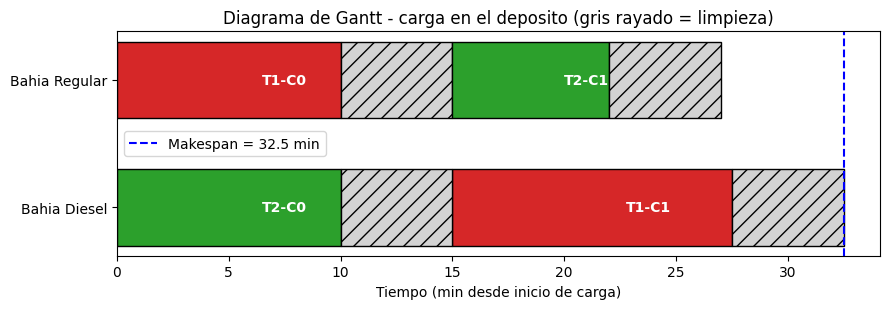

In [13]:

fig, ax = plt.subplots(figsize=(9,3.2))
colors = {'T1':'tab:red','T2':'tab:green'}
bay_y = {'R':10, 'D':0}
for oid, k, bay, vol, p in ops:
    s0 = start[oid]; dur = duracion[oid]
    ax.barh(bay_y[bay], dur-LIMPIEZA, left=s0, height=6, color=colors[k], edgecolor='k')
    ax.barh(bay_y[bay], LIMPIEZA, left=s0+dur-LIMPIEZA, height=6, color='lightgray', edgecolor='k', hatch='//')
    ax.text(s0+dur/2, bay_y[bay], oid, ha='center', va='center', color='white', fontweight='bold')
ax.set_yticks([0,10]); ax.set_yticklabels(['Bahia Diesel','Bahia Regular'])
ax.set_xlabel("Tiempo (min desde inicio de carga)")
ax.axvline(mk, color='blue', ls='--', label=f"Makespan = {mk:.1f} min")
ax.set_title("Diagrama de Gantt - carga en el deposito (gris rayado = limpieza)")
ax.legend(); plt.tight_layout(); plt.show()


In [14]:

print("Verificacion de horas de salida:")
print(f"  Makespan total de carga = {mk:.1f} min.")

# Justificacion de la hora de inicio de carga:
# El makespan es 32.5 min, por lo tanto la carga debe comenzar antes de:
#   T1 sale a las 05:00 (300 min) -> inicio maximo = 300 - 32.5 = 267.5 min = 04:27
#   T2 sale a las 05:30 (330 min) -> no es el cuello de botella
# Se elige 04:00 (240 min) como hora de inicio conservadora,
# lo que da una holgura minima de 300 - 240 - 32.5 = 27.5 min para T1.
hora_inicio_carga = 4 * 60   # 04:00 en minutos desde medianoche

print(f"  Hora de inicio de carga elegida: {hhmm(hora_inicio_carga)}")
print(f"  (Holgura sobre el inicio maximo posible: {300 - hora_inicio_carga - mk:.1f} min)")
print()

for camion in ('T1', 'T2'):
    # Tiempo en que ese camion termina su ultima operacion de carga
    fin_carga = hora_inicio_carga + max(start[op] + duracion[op] for op in ops_por_camion[camion])
    holgura   = TRUCKS[camion]['depart'] - fin_carga
    estado    = "OK" if holgura >= 0 else "NO ALCANZA"
    print(f"  {camion}: carga lista a las {hhmm(fin_carga)} | "
          f"hora de salida {hhmm(TRUCKS[camion]['depart'])} | "
          f"holgura {holgura:.1f} min -> {estado}")


Verificacion de horas de salida:
  Makespan total de carga = 32.5 min.
  Hora de inicio de carga elegida: 04:00
  (Holgura sobre el inicio maximo posible: 27.5 min)

  T1: carga lista a las 04:32 | hora de salida 05:00 | holgura 27.5 min -> OK
  T2: carga lista a las 04:27 | hora de salida 05:30 | holgura 63.0 min -> OK


**Interpretación (Parte 2).** El cuello de botella es la **bahía de Diésel** (17,5 + 15 = 32,5 min de trabajo), que fija la cota inferior del makespan. La secuencia óptima carga en paralelo ambas bahías: Regular hace `T1-C0 → T2-C1` y Diésel hace `T2-C0 → T1-C1`, alcanzando el **makespan = 32,5 min**, igual a la cota inferior (óptimo). Iniciando la carga a las 04:00, T1 queda listo a las 04:32 (sale 05:00) y T2 a las 04:27 (sale 05:30): **ambos camiones pueden salir a su hora programada**.

## Parte 3 — Análisis de la solución propuesta por el operador

| Camión | Ruta | C0 | C1 | Fill C0 | Fill C1 |
|---|---|---|---|---|---|
| T1 | D→1→3→D | Regular | Diésel | 62.5% | 71.4% |
| T2 | D→2→4→D | Diésel | Regular | 66.7% | 38.9% |

El operador declara: **costo de distancia = \$260** y **shortage = 0**.

Reconstruimos la solución a partir de los fill ratios (volumen cargado = fill × capacidad) y la verificamos numéricamente.

In [15]:

prop_routes = {'T1':[1,3], 'T2':[2,4]}
prop_orient = {'T1':0, 'T2':1}
prop_loads  = {'T1':(5000,5000), 'T2':(3500,4000)}

res_prop = evaluar_solucion(prop_routes, prop_orient, DEM_S1, loads=prop_loads)
print("Cargas reconstruidas (fill ratio x capacidad):")
print("  T1: Regular 5000 L (62.5% de 8000), Diesel 5000 L (71.4% de 7000)")
print("  T2: Regular 3500 L (38.9% de 9000), Diesel 4000 L (66.7% de 6000)")


Cargas reconstruidas (fill ratio x capacidad):
  T1: Regular 5000 L (62.5% de 8000), Diesel 5000 L (71.4% de 7000)
  T2: Regular 3500 L (38.9% de 9000), Diesel 4000 L (66.7% de 6000)


### a) Verificación de factibilidad

**(i) Capacidad de compartimentos** — ¿cabe el volumen a entregar en cada compartimento?

In [16]:

filas = []
for nombre in ('T1', 'T2'):
    r     = res_prop['info'][nombre]
    orden = prop_routes[nombre]
    dem_reg = sum(DEM_S1[s][0] for s in orden)
    dem_die = sum(DEM_S1[s][1] for s in orden)
    filas.append(dict(
        Camion       = nombre,
        Producto     = 'Regular',
        Demanda_ruta = dem_reg,
        Capacidad    = int(r['cap_reg']),
        Cargado      = int(r['load_reg']),
        Cabe         = "Si" if dem_reg <= r['cap_reg'] else "No",
    ))
    filas.append(dict(
        Camion       = nombre,
        Producto     = 'Diesel',
        Demanda_ruta = dem_die,
        Capacidad    = int(r['cap_die']),
        Cargado      = int(r['load_die']),
        Cabe         = "Si" if dem_die <= r['cap_die'] else "No",
    ))
display(pd.DataFrame(filas))

print("Los compartimentos tienen capacidad fisica suficiente para toda la demanda de cada ruta.")
print()
print("Sin embargo, el operador cargo MENOS litros de Regular de los necesarios:")
print("  T1: cargo 5.000 L pero la demanda de Regular en su ruta es 5.500 L -> shortage de 500 L")
print("  T2: cargo 3.500 L pero la demanda de Regular en su ruta es 5.000 L -> shortage de 1.500 L")
print()
print("Conclusion: la infactibilidad no es por falta de capacidad del compartimento,")
print("sino por una decision de carga incorrecta del operador.")


,Camion,Producto,Demanda_ruta,Capacidad,Cargado,Cabe
0,T1,Regular,5500,8000,5000,Si
1,T1,Diesel,5000,7000,5000,Si
2,T2,Regular,5000,9000,3500,Si
3,T2,Diesel,4000,6000,4000,Si


Los compartimentos tienen capacidad fisica suficiente para toda la demanda de cada ruta.

Sin embargo, el operador cargo MENOS litros de Regular de los necesarios:
  T1: cargo 5.000 L pero la demanda de Regular en su ruta es 5.500 L -> shortage de 500 L
  T2: cargo 3.500 L pero la demanda de Regular en su ruta es 5.000 L -> shortage de 1.500 L

Conclusion: la infactibilidad no es por falta de capacidad del compartimento,
sino por una decision de carga incorrecta del operador.


**(ii) Estabilidad ($\Delta=0.30$)** — fill ratio de cada compartimento en cada instante.

In [17]:

rows=[]
for tn in ('T1','T2'):
    r=res_prop['info'][tn]
    for inst,(f0,f1) in zip(r['instants'], r['fills']):
        diff=abs(f0-f1)
        rows.append(dict(Camion=tn, Instante=inst, FillC0=f"{f0*100:.1f}%", FillC1=f"{f1*100:.1f}%",
                         Diferencia=f"{diff*100:.1f}%", Estado="OK" if diff<=DELTA+1e-9 else "VIOLA D=30%"))
display(pd.DataFrame(rows))
print("Estabilidad global:", "OK" if res_prop['stab_ok'] else "VIOLADA")


,Camion,Instante,FillC0,FillC1,Diferencia,Estado
0,T1,Salida deposito,62.5%,71.4%,8.9%,OK
1,T1,Tras Est.1,25.0%,42.9%,17.9%,OK
2,T1,Tras Est.3,0.0%,0.0%,0.0%,OK
3,T2,Salida deposito,66.7%,38.9%,27.8%,OK
4,T2,Tras Est.2,41.7%,0.0%,41.7%,VIOLA D=30%
5,T2,Tras Est.4,0.0%,0.0%,0.0%,OK


Estabilidad global: VIOLADA


**(iii) Ventanas de tiempo** — hora de llegada estimada a cada estación (60 km/h, servicio 30 min).

In [18]:

rows=[]
for tn in ('T1','T2'):
    r=res_prop['info'][tn]
    for s in prop_routes[tn]:
        a,b=WIN[s]; arr=r['arrivals'][s]
        if arr> b+1e-6: estado="LLEGA TARDE"
        elif arr< a-1e-6: estado="llega antes (espera)"
        else: estado="dentro de ventana"
        rows.append(dict(Camion=tn, Estacion=f"Est.{s}", Llegada=hhmm(arr),
                         Ventana=f"[{hhmm(a)}-{hhmm(b)}]", Estado=estado))
display(pd.DataFrame(rows))
print("Ventanas (sin llegadas tarde):", "OK" if res_prop['tw_ok'] else "hay llegadas tarde")
print("Nota: varias llegadas son ANTES de a_j; si se permite esperar, son admisibles.")


,Camion,Estacion,Llegada,Ventana,Estado
0,T1,Est.1,05:20,[06:00-10:00],llega antes (espera)
1,T1,Est.3,06:55,[08:00-14:00],llega antes (espera)
2,T2,Est.2,06:05,[07:00-12:00],llega antes (espera)
3,T2,Est.4,07:45,[06:00-11:00],dentro de ventana


Ventanas (sin llegadas tarde): OK
Nota: varias llegadas son ANTES de a_j; si se permite esperar, son admisibles.


### b) Verificación del costo declarado

In [19]:

print("=== COSTO REAL de la solucion propuesta ===")
print(f"  (1) Distancia: T1={res_prop['info']['T1']['dist']:.0f} km + "
      f"T2={res_prop['info']['T2']['dist']:.0f} km = {res_prop['dist']:.0f} km  ->  ${res_prop['dist_cost']:.0f}")
print(f"  (2) Costos fijos: T1 $500 + T2 $400 = ${res_prop['fixed']:.0f}")
print(f"  (3) Shortage: {res_prop['short']:.0f} L de Regular  ->  ${res_prop['short_cost']:.0f}")
print(f"  COSTO TOTAL REAL = ${res_prop['total']:.0f}")
print()
print("=== COMPARACION con lo declarado ===")
print(f"  Distancia declarada $260  vs  real ${res_prop['dist_cost']:.0f}  -> ERROR")
print(f"  Shortage declarado 0 L    vs  real {res_prop['short']:.0f} L  -> ERROR")
print(f"  Ademas el operador OMITE los costos fijos (${res_prop['fixed']:.0f}).")


=== COSTO REAL de la solucion propuesta ===
  (1) Distancia: T1=60 km + T2=90 km = 150 km  ->  $300
  (2) Costos fijos: T1 $500 + T2 $400 = $900
  (3) Shortage: 2000 L de Regular  ->  $20000
  COSTO TOTAL REAL = $21200

=== COMPARACION con lo declarado ===
  Distancia declarada $260  vs  real $300  -> ERROR
  Shortage declarado 0 L    vs  real 2000 L  -> ERROR
  Ademas el operador OMITE los costos fijos ($900).


**Conclusión 3a–3b.**
- **Capacidad:** todos los compartimentos podrían contener la demanda de su ruta, pero el operador **cargó de menos** el Regular.
- **Estabilidad:** **T1 cumple** (diferencia máx. 17,9%); **T2 VIOLA** la restricción: tras entregar en Est.2 el Regular cae a 0% mientras el Diésel queda en 41,7% (diferencia 41,7% > 30%).
- **Ventanas:** no hay llegadas *tarde*; varias llegadas son *anticipadas* (admisibles sólo si se permite esperar).
- **Costo declarado FALSO:** la distancia real es **\$300** (no \$260) y existe **shortage de 2.000 L de Regular** = **\$20.000**; además omite **\$900** de costos fijos.

### c) Propuesta de mejora

In [20]:

print("Si solo se carga mas (sin cambiar la ruta de T2):")
imp_loads = {'T1':(5500,5000), 'T2':(5000,4000)}
res_a = evaluar_solucion(prop_routes, prop_orient, DEM_S1, loads=imp_loads)
print(f"  estabilidad OK={res_a['stab_ok']}")

print("\nMEJORA propuesta: cargar a demanda + invertir ruta de T2 (D->4->2->D):")
imp_routes = {'T1':[1,3], 'T2':[4,2]}
res_imp = evaluar_solucion(imp_routes, prop_orient, DEM_S1, loads=imp_loads)
for tn in ('T1','T2'):
    r=res_imp['info'][tn]
    diffs=[abs(f0-f1) for f0,f1 in r['fills']]
    print(f"  {tn}: ruta D->{'->'.join(str(s) for s in imp_routes[tn])}->D | "
          f"dif. estabilidad max={max(diffs)*100:.1f}% | tarde={r['late']}")
print(f"\n  Costo: distancia ${res_imp['dist_cost']:.0f} + fijo ${res_imp['fixed']:.0f} + "
      f"shortage ${res_imp['short_cost']:.0f} = ${res_imp['total']:.0f}")
print(f"  Factible: estabilidad={res_imp['stab_ok']}, ventanas={res_imp['tw_ok']}")
print(f"  Ahorro vs. operador: ${res_prop['total']:.0f} -> ${res_imp['total']:.0f} (${res_prop['total']-res_imp['total']:.0f})")


Si solo se carga mas (sin cambiar la ruta de T2):
  estabilidad OK=False

MEJORA propuesta: cargar a demanda + invertir ruta de T2 (D->4->2->D):
  T1: ruta D->1->3->D | dif. estabilidad max=11.6% | tarde=False
  T2: ruta D->4->2->D | dif. estabilidad max=19.4% | tarde=False

  Costo: distancia $300 + fijo $900 + shortage $0 = $1200
  Factible: estabilidad=True, ventanas=True
  Ahorro vs. operador: $21200 -> $1200 ($20000)


**Mejora (3c).** Dos cambios *factibles*:
1. **Cargar el Regular hasta la demanda** (hay capacidad ociosa): T1 → 5.500 L y T2 → 5.000 L. Esto **elimina los \$20.000 de shortage**.
2. **Invertir la ruta de T2** a `D→4→2→D` (misma distancia). Entregar primero en Est.4 mantiene el balance de fill ratios y **respeta la estabilidad** en todo instante.

Resultado: costo total **\$1.200** frente a los **\$21.200** reales del operador. El **óptimo global** (T1: Est.1→2→4, T2: Est.3) alcanza **\$1.130**.

## Parte 4 — Extensión estocástica de dos etapas

La demanda es incierta; se consideran 3 escenarios.

| Escenario | Prob. | E1 (R,D) | E2 (R,D) | E3 (R,D) | E4 (R,D) |
|---|---|---|---|---|---|
| s=1 Normal | 0.5 | (3000,2000) | (4000,1500) | (2500,3000) | (1000,2500) |
| s=2 Alta   | 0.3 | (4500,2800) | (5500,2000) | (3500,3000) | (1000,2500) |
| s=3 Baja   | 0.2 | (2000,1200) | (3000,1000) | (1800,3000) | (1000,2500) |

### a) Modelo de dos etapas

**Decisiones de PRIMERA etapa** (antes de conocer la demanda): $z_k$, $x_{ijk}$, $\alpha_{kmp}$, $L_{kmp}$.

**Decisiones de SEGUNDA etapa** (recourse, tras observar $\xi_s$): entregas $q_{jkp}^{s}$ y shortage $w_{jp}^{s}$.

**Función objetivo:**
$$\min\;\sum_k F_k z_k \;+\; cf\sum_{i,j,k} d_{ij}x_{ijk}\;+\;\sum_{s} P_s\Big(cs\sum_{j,p} w_{jp}^{s}\Big)$$

### b) Resolución con la metaheurística
Primera etapa: rutas + orientación + cargas $L=\min(\text{cap},\,\max_s \text{demanda asignada})$. Se optimizan por **costo esperado** con el mismo Algoritmo Genético.

In [21]:

SCEN = {
    's1': dict(p=0.5, dem={1:(3000,2000),2:(4000,1500),3:(2500,3000),4:(1000,2500)}),
    's2': dict(p=0.3, dem={1:(4500,2800),2:(5500,2000),3:(3500,3000),4:(1000,2500)}),
    's3': dict(p=0.2, dem={1:(2000,1200),2:(3000,1000),3:(1800,3000),4:(1000,2500)}),
}

def first_stage_loads(routes, orient):
    loads={}
    for tn,order in routes.items():
        if not order: continue
        reg=max(sum(SCEN[s]['dem'][j][0] for j in order) for s in SCEN)
        die=max(sum(SCEN[s]['dem'][j][1] for j in order) for s in SCEN)
        loads[tn]=(reg,die)
    return loads

def expected_cost(routes, orient):
    loads=first_stage_loads(routes, orient)
    base=evaluar_solucion(routes, orient, SCEN['s1']['dem'], loads=loads)
    first=base['dist_cost']+base['fixed']
    exp_short=0.0; stab_all=True; tw_all=True; per=[]
    for s,info in SCEN.items():
        r=evaluar_solucion(routes, orient, info['dem'], loads=loads)
        exp_short+=info['p']*r['short_cost']
        stab_all=stab_all and r['stab_ok']; tw_all=tw_all and r['tw_ok']
        per.append(dict(Escenario=s, Prob=info['p'], Shortage_L=r['short'],
                        Costo_shortage=r['short_cost'], EstabOK=r['stab_ok'], VentOK=r['tw_ok']))
    return first+exp_short, first, exp_short, stab_all, tw_all, per, loads

def fitness_sto(genome):
    routes,orient=decodificar_genoma(genome, SCEN['s1']['dem'])
    ec,_,_,stab,tw,_,_=expected_cost(routes,orient)
    pen=0 if (stab and tw) else 1e7
    return ec+pen, routes, orient

def ga_stochastic(pop=30, gens=40, pm=0.15, seed=3):
    rng=random.Random(seed)
    pop_list=[[rng.randint(0,1) for _ in range(6)] for _ in range(pop)]
    best=None; hist=[]
    for g in range(gens):
        scored=sorted(((fitness_sto(ind)[0],ind) for ind in pop_list), key=lambda x:x[0])
        if best is None or scored[0][0]<best[0]: best=(scored[0][0], list(scored[0][1]))
        hist.append(best[0])
        new=[list(scored[0][1]),list(scored[1][1])]
        def tour():
            a,b=rng.choice(scored),rng.choice(scored); return a[1] if a[0]<b[0] else b[1]
        while len(new)<pop:
            p1,p2=tour(),tour()
            c=[p1[i] if rng.random()<0.5 else p2[i] for i in range(6)]
            c=[(1-b) if rng.random()<pm else b for b in c]
            new.append(c)
        pop_list=new
    routes,orient=decodificar_genoma(best[1], SCEN['s1']['dem'])
    return best,hist,routes,orient

best_s,hist_s,routes_s,orient_s=ga_stochastic()
ec,first,exp_short,stab,tw,per,loads_s=expected_cost(routes_s,orient_s)

print("===== SOLUCION ESTOCASTICA DE DOS ETAPAS (1a etapa) =====")
for tn in ('T1','T2'):
    if routes_s[tn]:
        rc='C0' if orient_s[tn]==0 else 'C1'
        print(f"  {tn}: D->{'->'.join('E'+str(s) for s in routes_s[tn])}->D | Regular en {rc} | "
              f"carga (Reg,Die)={tuple(int(x) for x in loads_s[tn])}")
print(f"\n  Costo 1a etapa (fijo+distancia) = ${first:.0f}")
print(f"  Costo esperado de shortage (2a etapa) = ${exp_short:.0f}")
print(f"  >> COSTO TOTAL ESPERADO = ${ec:.0f}")
display(pd.DataFrame(per))


===== SOLUCION ESTOCASTICA DE DOS ETAPAS (1a etapa) =====
  T1: D->E2->E4->D | Regular en C0 | carga (Reg,Die)=(6500, 4500)
  T2: D->E1->E3->D | Regular en C1 | carga (Reg,Die)=(8000, 5800)

  Costo 1a etapa (fijo+distancia) = $1200
  Costo esperado de shortage (2a etapa) = $0
  >> COSTO TOTAL ESPERADO = $1200


,Escenario,Prob,Shortage_L,Costo_shortage,EstabOK,VentOK
0,s1,0.5,0.0,0.0,True,True
1,s2,0.3,0.0,0.0,True,True
2,s3,0.2,0.0,0.0,True,True


Costo esperado de la solucion (recourse)        : $1200
Costo 'wait-and-see' (informacion perfecta, WS) : $1151
EVPI (valor esperado de la informacion perfecta): $49


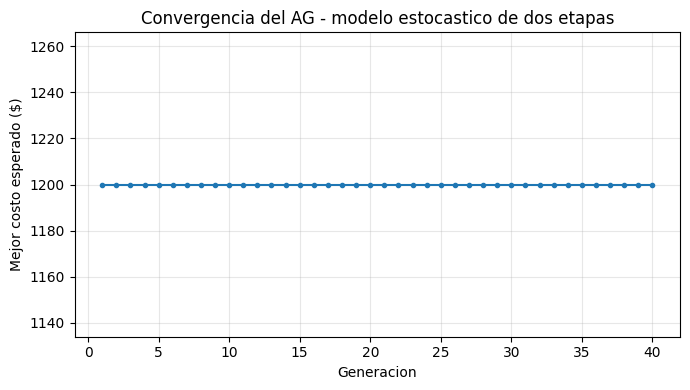

In [22]:

ws=0.0
for s,info in SCEN.items():
    _,_,_,res=resolver_exacto(info['dem'])
    ws+=info['p']*res['total']
print(f"Costo esperado de la solucion (recourse)        : ${ec:.0f}")
print(f"Costo 'wait-and-see' (informacion perfecta, WS) : ${ws:.0f}")
print(f"EVPI (valor esperado de la informacion perfecta): ${ec-ws:.0f}")

fig,ax=plt.subplots(figsize=(7,4))
ax.plot(range(1,len(hist_s)+1),hist_s,marker='o',ms=3)
ax.set_xlabel("Generacion"); ax.set_ylabel("Mejor costo esperado ($)")
ax.set_title("Convergencia del AG - modelo estocastico de dos etapas")
ax.grid(alpha=.3); plt.tight_layout(); plt.show()


**Interpretación (Parte 4).** La solución de dos etapas fija rutas, asignación y **cargas** *antes* de conocer la demanda, cargando para el escenario alto hasta donde la capacidad lo permite. El **EVPI** cuantifica cuánto se ganaría si la demanda se conociera de antemano.

---
## Conclusiones generales

- La metaheurística (**Algoritmo Genético**) resuelve el ruteo con compartimentos, estabilidad y ventanas, y **coincide con el óptimo exacto** en el caso determinista (validación cruzada).
- El **scheduling de carga** alcanza un makespan de **32,5 min** (igual a la cota inferior), permitiendo que ambos camiones salgan a su hora.
- La solución del operador (Parte 3) es **infactible** (viola estabilidad en T2) y su costo declarado es **falso**: el costo real (\$21.200) está dominado por **\$20.000 de shortage**; una mejora simple lo reduce a **\$1.200**.
- El **modelo estocástico de dos etapas** separa decisiones here-and-now (rutas/cargas) de recourse (entregas/shortage) y cuantifica el impacto de la incertidumbre mediante el costo esperado y el EVPI.
